# data load 


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load data
df = pd.read_csv(r'C:\Users\ThinkPad\Downloads\Attack_Dataset.csv')
df.columns = df.columns.str.strip()

# Bikin 3 kolom numerik
df['desc_len'] = df['Scenario Description'].str.len()
df['steps_len'] = df['Attack Steps'].str.len()
df['tools_count'] = df['Tools Used'].str.count(',') + 1

print("Shape:", df.shape)
df[['desc_len', 'steps_len', 'tools_count']].head()

Shape: (14133, 19)


,desc_len,steps_len,tools_count
0,117,658,3.0
1,219,784,4.0
2,220,896,4.0
3,245,1274,5.0
4,304,1162,5.0


# Boxplot 3 Kolom

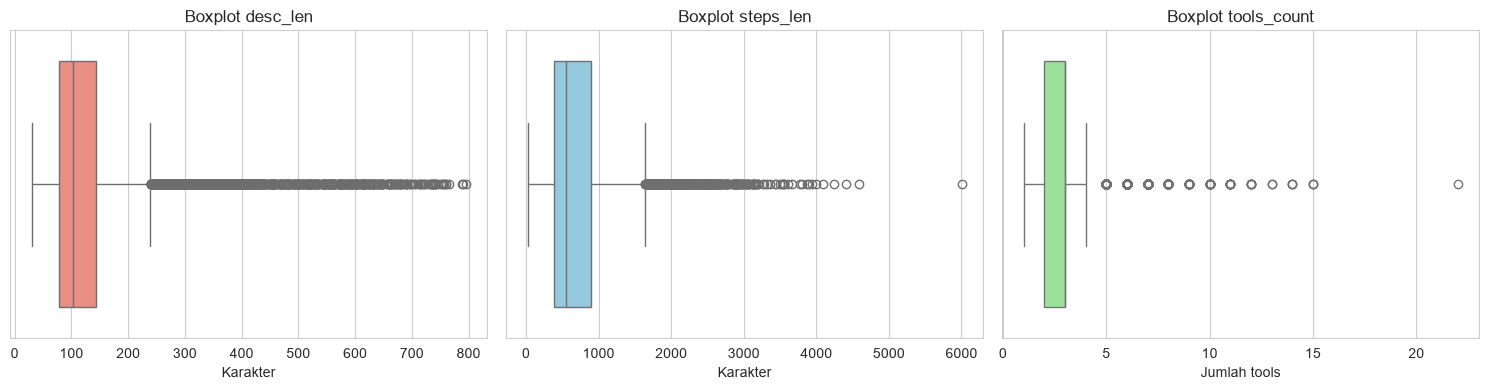

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x=df['desc_len'], ax=axes[0], color='salmon')
axes[0].set_title('Boxplot desc_len')
axes[0].set_xlabel('Karakter')

sns.boxplot(x=df['steps_len'], ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot steps_len')
axes[1].set_xlabel('Karakter')

sns.boxplot(x=df['tools_count'], ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot tools_count')
axes[2].set_xlabel('Jumlah tools')

plt.tight_layout()
plt.show()

Ketiga boxplot menunjukkan adanya beberapa nilai yang jauh lebih tinggi dibandingkan data lainnya. Nilai seperti ini disebut **pencilan (outlier)**.

Pada `steps_len`, terdapat beberapa data dengan panjang langkah yang sangat besar, bahkan lebih dari **3.000 karakter**. Sementara itu, `tools_count` juga memiliki beberapa data yang menggunakan hingga **22 tools**. Sedangkan pada `desc_len`, outliernya tidak sejauh dua variabel lainnya.

**Kesimpulan:** Sebagian besar serangan memiliki ukuran dan jumlah tools yang normal, tetapi ada beberapa serangan yang jauh lebih panjang atau menggunakan lebih banyak tools. Hal ini menunjukkan bahwa serangan tertentu membutuhkan proses yang lebih rumit atau lebih detail dibandingkan serangan lainnya.

# Cek Outlier 1.5 x IQR

In [8]:
for k in ['desc_len', 'steps_len', 'tools_count']:
    Q1 = df[k].quantile(0.25)
    Q3 = df[k].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[k] < lower) | (df[k] > upper)]
    print(f"{k}: {len(outliers)} outlier (batas {lower:.1f} – {upper:.1f})")

desc_len: 891 outlier (batas -17.0 – 239.0)
steps_len: 652 outlier (batas -367.5 – 1644.5)
tools_count: 1136 outlier (batas 0.5 – 4.5)


### Interpretasi

Dengan menggunakan aturan **1,5 × IQR**, diperoleh jumlah pencilan (outlier) untuk masing-masing kolom numerik:

| Kolom | Jumlah Outlier | Batas Bawah | Batas Atas |
|---|---|---|---|
| `desc_len` | 891 | -17,0 | 239,0 |
| `steps_len` | 652 | -367,5 | 1.644,5 |
| `tools_count` | 1.136 | 0,5 | 4,5 |

- **`desc_len`** memiliki **891 outlier**, yaitu deskripsi yang panjangnya di atas **239 karakter**.
- **`steps_len`** memiliki **652 outlier**, yaitu langkah serangan yang panjangnya di atas **1.644,5 karakter**.
- **`tools_count`** memiliki **1.136 outlier**, yaitu serangan yang menggunakan lebih dari **4,5 tools** (artinya 5 tools ke atas).

**Kesimpulan:** Ketiga kolom memiliki pencilan di sisi kanan, yang berarti ada sebagian kecil serangan dengan tingkat kompleksitas yang jauh di atas mayoritas - baik dari sisi panjang deskripsi, panjang langkah, maupun jumlah tools yang digunakan. `tools_count` memiliki jumlah outlier terbanyak (1.136), sedangkan `steps_len` memiliki outlier dengan nilai paling ekstrem (hingga 6.003 karakter).

# Diagram Batang Kategorik

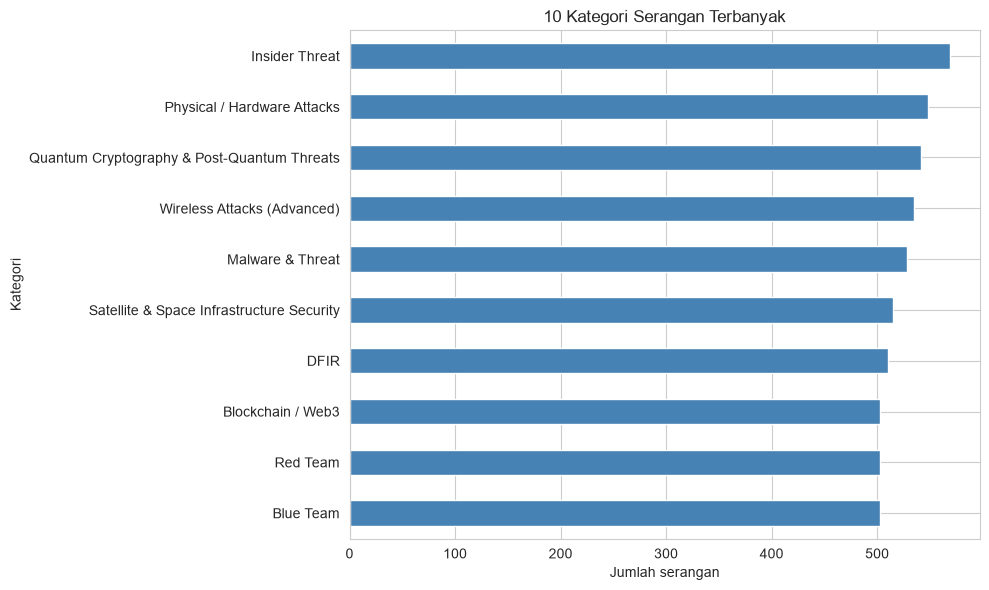

In [9]:
df['Category'].value_counts().head(10).plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('10 Kategori Serangan Terbanyak')
plt.xlabel('Jumlah serangan')
plt.ylabel('Kategori')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Diagram batang menunjukkan **10 kategori serangan yang paling sering muncul** dalam data.

Kategori **Insider Threat** memiliki jumlah paling banyak, yaitu **569 serangan**. Setelah itu ada **Physical/Hardware Attacks** sebanyak **548 serangan** dan **Quantum Cryptography** sebanyak **542 serangan**.

Jumlah 10 kategori teratas berada di sekitar **500–569 serangan**, sehingga perbedaannya tidak terlalu jauh.

**Kesimpulannya:** tidak ada satu kategori serangan yang jumlahnya jauh lebih banyak dari kategori lainnya. Data serangan **tersebar cukup merata di antara berbagai kategori**.


# Nilai Plus: Groupby Median per Kategori

Category
Blue Team                                       68.0
DFIR                                            75.0
Physical / Hardware Attacks                     77.0
Malware & Threat                                82.0
Red Team                                        82.0
Satellite & Space Infrastructure Security       84.0
Insider Threat                                  89.0
Wireless Attacks (Advanced)                     97.0
Quantum Cryptography & Post-Quantum Threats    119.0
Blockchain / Web3                              150.0
Name: desc_len, dtype: float64


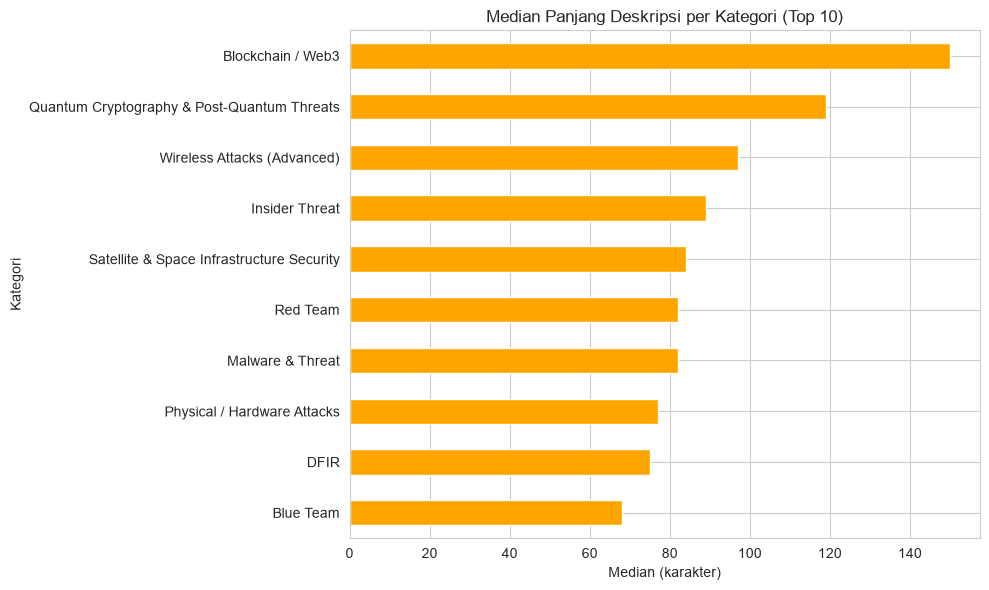

In [10]:
top_cat = df['Category'].value_counts().head(10).index
subset = df[df['Category'].isin(top_cat)]

median_per_cat = subset.groupby('Category')['desc_len'].median().sort_values()

print(median_per_cat)

median_per_cat.plot(kind='barh', color='orange', figsize=(10, 6))
plt.title('Median Panjang Deskripsi per Kategori (Top 10)')
plt.xlabel('Median (karakter)')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()



Median adalah **nilai tengah** dari data. Jadi, grafik ini menunjukkan **panjang deskripsi yang biasanya dimiliki oleh setiap kategori serangan**.

Nilai median panjang deskripsi berbeda-beda di setiap kategori. Kategori dengan median paling tinggi berarti **deskripsi serangannya biasanya lebih panjang dan lebih detail**. Sebaliknya, kategori dengan median paling rendah berarti **deskripsinya cenderung lebih singkat**.

**Kesimpulannya:** setiap kategori memiliki tingkat detail deskripsi yang berbeda-beda. Ada kategori yang biasanya dijelaskan dengan lebih panjang, dan ada juga yang cukup dijelaskan secara singkat.


# Kesimpulan

### Jawaban Pertanyaan

1. **Rata-rata panjang deskripsi serangan** adalah **127,57 karakter**. Nilai rata-ratanya lebih besar dari nilai tengahnya (median 103), sehingga sebagian data memiliki deskripsi yang jauh lebih panjang. Penyebaran datanya juga cukup beragam, dengan simpangan baku **90,93 karakter**.

2. **Rata-rata jumlah tools** yang digunakan dalam satu serangan adalah sekitar **2,94 tools**. Nilai ini hampir sama dengan mediannya, yaitu **3 tools**, sehingga jumlah tools yang digunakan cenderung **cukup stabil**, biasanya sekitar 2–3 tools.

3. **Rata-rata panjang langkah serangan** adalah **698,13 karakter**, sedangkan mediannya **554 karakter**. Perbedaan ini menunjukkan bahwa sebagian besar langkah serangan tidak terlalu panjang, tetapi ada beberapa serangan dengan langkah yang **sangat panjang**, bahkan mencapai **6.003 karakter**.

### 5 Temuan Menarik

1. **Insider Threat** merupakan kategori yang paling sering muncul, yaitu **569 serangan (4,03%)**.
2. `steps_len` memiliki variasi paling besar. Artinya, panjang langkah antarserangan bisa sangat berbeda.
3. `tools_count` merupakan data yang paling stabil. Mayoritas serangan menggunakan sekitar **2–3 tools**.
4. Terdapat banyak data yang berbeda cukup jauh dari mayoritas, yaitu **891 pada `desc_len`**, **652 pada `steps_len`**, dan **1.136 pada `tools_count`**.
5. Terdapat **64 kategori serangan**, tetapi jumlah datanya tidak sama. Hanya **10 kategori teratas** yang memiliki lebih dari 400 serangan, sedangkan kategori lainnya memiliki jumlah yang lebih sedikit.

### Keterbatasan Data

* Data ini lebih seperti **kumpulan informasi atau deskripsi tentang serangan**, bukan catatan serangan yang benar-benar terjadi di jaringan.
* Data bersifat **sintetis**, sehingga belum tentu menggambarkan kondisi serangan siber di dunia nyata.
* Beberapa informasi berupa teks yang panjang, sehingga lebih sulit untuk diubah menjadi angka dan dianalisis.
* Jumlah data pada setiap kategori berbeda-beda. Beberapa kategori memiliki banyak data, sementara kategori lainnya hanya memiliki sedikit data.

### Pertanyaan yang Bisa Diteliti Selanjutnya

Dari hasil analisis ini, kita masih bisa mencari tahu beberapa hal, misalnya:

* Apakah serangan yang menggunakan **lebih banyak tools** juga memiliki deskripsi yang lebih panjang?
* Kategori serangan mana yang memiliki **langkah-langkah paling panjang**?
* Apakah **panjang deskripsi** berhubungan dengan **panjang langkah serangan**?
* Apakah semakin banyak tools yang digunakan berarti langkah serangannya juga semakin panjang?

**Secara sederhana, dataset ini menunjukkan bahwa setiap serangan memiliki tingkat detail yang berbeda-beda. Kebanyakan serangan berada pada ukuran yang relatif normal, tetapi ada beberapa serangan yang jauh lebih panjang dan menggunakan lebih banyak tools.**


# Referensi & Catatan Penggunaan AI


## Tabel Penggunaan AI

| Alat | Dipakai untuk | Yang kami pelajari |
|---|---|---|
| ChatGPT | Menanyakan arti error `KeyError: 'pm 25'` | Nama kolom harus sama persis, termasuk spasi. Solusinya: `df.columns.str.strip()` |
| ChatGPT | Menanyakan beda **varians** dan **simpangan baku** | Varians = rata-rata kuadrat deviasi; simpangan baku = akar dari varians |
| ChatGPT | Menanyakan fungsi `df.info()` vs `df.describe()` | `df.info()` untuk tipe data & missing; `df.describe()` untuk statistik deskriptif numerik |
| ChatGPT | Menanyakan cara cek missing values dan persentasenya | `df.isna().sum()` untuk jumlah; `(df.isna().sum() / len(df)) * 100` untuk persentase |
| ChatGPT | Menanyakan cara hapus kolom yang tidak dipakai | `df.drop(columns=['Unnamed: 15'])` |
| ChatGPT | Menanyakan cara isi missing value dengan string | `df.fillna('Unknown')` |
| ChatGPT | Menanyakan fungsi `str.split(',').explode().str.strip()` | Memecah kolom teks berisi daftar (dipisah koma) menjadi baris terpisah, lalu dibersihkan spasinya |
| ChatGPT | Menanyakan regex `r'T\d{4}(?:\.\d{3})?'` | `T` + 4 digit, opsional `.` + 3 digit, untuk mengekstrak kode MITRE ATT&CK |
| ChatGPT | Menanyakan cara membuat kolom panjang teks | `df['Scenario Description'].str.len()` untuk panjang karakter |
| ChatGPT | Menanyakan cara membuat kolom jumlah tools | `df['Tools Used'].str.count(',') + 1`jumlah tools = jumlah koma + 1 |
| ChatGPT | Menanyakan cara cek outlier dengan aturan **1.5 × IQR** | `Q1 - 1.5*IQR` (batas bawah) dan `Q3 + 1.5*IQR` (batas atas); nilai di luar batas = outlier |
| ChatGPT | Menanyakan parameter `figsize`, `bins`, `edgecolor` di Matplotlib | `figsize` ukuran gambar; `bins` jumlah bin histogram; `edgecolor` warna garis tepi batang |
| ChatGPT | Menanyakan cara `groupby().median()` per kategori | `subset.groupby('Category')['desc_len'].median().sort_values()` untuk median per grup |
| ChatGPT | Menanyakan cara `invert_yaxis()` di barh | Membalik urutan sumbu Y agar kategori terbesar muncul di atas |
| ChatGPT | Menanyakan arti `pd.DataFrame(data_kamus)` dari list of dict | Membuat tabel kamus data dari struktur list berisi dict |
| ChatGPT | Menanyakan cara menampilkan tabel rapi di Jupyter | `from IPython.display import display; display(df_kamus)` |
| ChatGPT | Menanyakan cara `%matplotlib inline` dan `sns.set_style()` | `%matplotlib inline` agar grafik tampil di notebook; `set_style("whitegrid")` untuk tema grid putih |

---

## Referensi Penulisan Kode (dengan Link Sumber)

### 1. `df.columns.str.strip()` - Membersihkan spasi pada nama kolom

**file** (`tugas4(Afif).ipynb` - bagian *data load*):

```python
df.columns = df.columns.str.strip()
```

**Referensi:**
- [Pandas: Index.str.strip](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html) - dokumentasi resmi `.str.strip()` pada index/kolom.

---

### 2. `str.split(',').explode().str.strip()` - ngesplit 

**file** (`tugas2(fardhan).ipynb`):

```python
tools = df['Tools Used'].dropna().str.split(',').explode().str.strip()
```

**Referensi:**
- [Kanaries: Pandas String Operations](https://docs.kanaries.net/topics/Pandas/pandas-string-operations) - contoh `.str.split().explode().str.strip()`.

---

### 3. `Q1 = df.quantile(0.25)` dan `IQR = Q3 - Q1` - Deteksi outlier

**file** (`tugas4(Afif).ipynb` - bagian *Cek Outlier 1.5 x IQR*):

```python
Q1 = df[k].quantile(0.25)
Q3 = df[k].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[k] < lower) | (df[k] > upper)]
```

**Referensi:**
- [Stack Overflow: Remove Outliers in Pandas DataFrame using Percentiles](https://stackoverflow.com/questions/35827863/remove-outliers-in-pandas-dataframe-using-percentiles) - kode `Q1 = df.quantile(0.25)` dll.

---

### 4. `df['Category'].value_counts().head(10).plot(kind='barh')` - Diagram batang horizontal

**file** (`tugas4(Afif).ipynb` - bagian *Diagram Batang Kategorik*):

```python
df['Category'].value_counts().head(10).plot(kind='barh', color='steelblue', figsize=(10, 6))
```

**Referensi:**
- [Stack Overflow: How to plot bars from pandas value_counts](https://stackoverflow.com/questions/36762199/how-to-plot-bars-from-pandas-value-counts) - contoh `value_counts().plot(kind='barh')`.
- [Stack Overflow: Revisions 7b9e2c6f](https://stackoverflow.com/revisions/7b9e2c6f-cdf7-472a-93ad-2879f77790db/view-source) - memuat `.head(10).plot`.

---

### 5. `re.findall(r'T\d{4}(?:\.\d{3})?', str(x))` - extract kode MITRE

**file** (`tugas2(fardhan).ipynb` - bagian *Bagian Jason*):

```python
def extract_mitre(x):
    return re.findall(r'T\d{4}(?:\.\d{3})?', str(x))
```

**Referensi:**
- [Pandas: Series.str.findall](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.findall.html) - vektorisasi regex.

---

### 6. `subset.groupby('Category')['desc_len'].median()` - Median per grup

**file** (`tugas4(Afif).ipynb` - bagian *Groupby Median per Kategori*):

```python
median_per_cat = subset.groupby('Category')['desc_len'].median().sort_values()
```

**Referensi:**
- [Pandas: GroupBy.median](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.GroupBy.median.html) - dokumentasi resmi.

---

### 7. `df['Tools Used'].str.count(',') + 1` - Menghitung jumlah tools

**file** (`tugas4(Afif).ipynb` - bagian *data load*):

```python
df['tools_count'] = df['Tools Used'].str.count(',') + 1
```

**Referensi:**
- [Stack Overflow: Count separators in CSV rows with Pandas](https://stackoverflow.com/questions/53862765/count-separators-in-csv-rows-with-pandas) - pola `.str.count(',') + 1`.

---

### 8. `(df.isna().sum() / len(df)) * 100` - Persentase missing values

**file** (`tugas2(fardhan).ipynb` - bagian *Persentase Missing Values*):

```python
print((df.isna().sum() / len(df)) * 100)
```

**Referensi:**
- [Stack Overflow: Revision 4db32e01](https://stackoverflow.com/revisions/4db32e01-c36c-41b3-b5e2-1bf2a9f2539e/view-source) - rumus yang sama.

---

### 9. `fig, axes = plt.subplots(1, 3, figsize=(15, 4))` + `sns.boxplot` - Boxplot banyak kolom

**file** (`tugas4(Afif).ipynb` - bagian *Boxplot 3 Kolom*):

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=df['desc_len'], ax=axes[0], color='salmon')
```

**Referensi:**
- [Arab Psychology: Adjust Figure Size of Seaborn Plot](https://scales.arabpsychology.com/stats/how-can-the-figure-size-of-a-seaborn-plot-be-adjusted/) - contoh `plt.subplots` + `sns.boxplot`.

---

### 10. `df.fillna('Unknown')` - Mengisi missing value

**file** (`tugas2(fardhan).ipynb` - bagian *Pembersihan Data*):

```python
df = df.fillna('Unknown')
```

**Referensi:**
- [Pandas: DataFrame.fillna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html) - dokumentasi resmi.

---

### 11. `df.duplicated().sum()` - Memeriksa baris duplikat

**file** (`tugas2(fardhan).ipynb` - bagian *Pemeriksaan Data Duplikat*):

```python
print("Jumlah duplikat:", df.duplicated().sum())
```

**Referensi:**
- [Pandas: DataFrame.duplicated](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html) - dokumentasi resmi.
- [GeeksforGeeks: Pandas duplicated](https://www.geeksforgeeks.org/python-pandas-dataframe-duplicated/) - penjelasan & contoh.

---

### 12. `df.drop(columns=['Unnamed: 15'])` - Menghapus kolom

**file** (`tugas2(fardhan).ipynb` - bagian *Pembersihan Data*):

```python
df = df.drop(columns=['Unnamed: 15'])
```

**Referensi:**
- [Pandas: DataFrame.drop](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) - dokumentasi resmi.

---

### 13. `df.info()` - Melihat tipe data dan missing

**file** (`tugas2(fardhan).ipynb` - bagian *Pemeriksaan Tipe Data*):

```python
print(df.info())
```

**Referensi:**
- [Pandas: DataFrame.info](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) - dokumentasi resmi.
- [W3Schools: Pandas DataFrame info()](https://www.w3schools.com/python/pandas/ref_df_info.asp) - penjelasan.

---

### 14. `display(df_kamus)` - Menampilkan tabel di Jupyter

**file** (`tugas1(rafky).ipynb` - bagian *Kamus Data*):

```python
from IPython.display import display
display(df_kamus)
```

**Referensi:**
- [IPython: display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html) - dokumentasi resmi.

---


## Referensi Sumber Dataset

- **Dataset:** [Kaggle - Cybersecurity Attack and Defence Dataset](https://www.kaggle.com/datasets/tannubarot/cybersecurity-attack-and-defence-dataset)
- **Lisensi:** MIT License

## Referensi Workflow EDA

- **Data Science for Beginners (GitHub)** - https://github.com/Srdiegoibs/Data-Science-For-Beginners

---